# Logic Grid Puzzle Solver

> *Every logic puzzle is a constraint satisfaction problem in disguise.*

A logic grid puzzle gives you N categories with N items each and a set of
clues ("the Norwegian lives next to the blue house"). Your job is to find
the unique assignment that satisfies every clue simultaneously.

This is a **Constraint Satisfaction Problem (CSP)** the same computational
structure as Sudoku, map coloring, and scheduling. The same algorithm solves all of them:

1. **Represent** the problem as candidate sets (what is still possible for each cell)
2. **Propagate** constraints to eliminate impossible candidates
3. **Backtrack** with MRV (most constrained cell first) when propagation stalls

The connection to `sudoku.py` this notebook opens by comparing
the two structures, then shows the shared algorithm solving both.


In [1]:
# Imports
import sys, time, math
from copy import deepcopy
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import time

import solver  as sv
import puzzles as pz

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0d1b2a",
    "axes.facecolor":   "#0d1b2a",
    "text.color":       "#dde8f0",
    "axes.edgecolor":   "#2a4a6a",
    "axes.labelcolor":  "#dde8f0",
    "xtick.color":      "#dde8f0",
    "ytick.color":      "#dde8f0",
    "grid.color":       "#1e3040",
    "grid.alpha":       0.4,
})
# print("solver.py  :", sv.__file__)
# print("puzzles.py :", pz.__file__)
print("Imports complete.")

Imports complete.


## The Shared CSP Skeleton

Before solving any puzzle, let's make the connection between logic grids
and Sudoku explicit. Both are constraint satisfaction problems with the
same structure:

| | Sudoku | Logic Grid |
|---|---|---|
| **Variables** | 81 cells | N × K cells |
| **Domains** | digits 1–9 | items 0..N-1 |
| **Constraints** | one digit per row/col/box | one item per entity/category |
| **Algorithm** | propagation and backtracking | propagation and backtracking |
| **MRV heuristic** | fewest candidates in any cell | fewest candidates in any cell |

The only difference is geometry. In Sudoku, peers are rows, columns, and boxes.
In a logic grid, peers are all entities sharing a category (no two entities
can have the same item in the same category).

In [2]:
# Show the candidate structure for the 3x3 Colors puzzle before solving
puzzle_small = pz.make_colors_puzzle()
cands_init   = sv.make_candidates(puzzle_small)

total_init = sum(len(s) for s in cands_init.values())
print("3x3 Colors puzzle initial candidates (before any propagation)")
print(f"Total candidates: {total_init} (= {puzzle_small.n} entities × "
      f"{len(puzzle_small.categories)} categories × {puzzle_small.n} items each)")
print(f"{'Cell':<20} Candidates")
for e in range(puzzle_small.n):
    for c, cat in enumerate(puzzle_small.categories):
        items = [puzzle_small.items[cat][i]
                 for i in sorted(cands_init[(e, c)])]
        print(f"  house {e+1}, {cat:<10} {items}")

3x3 Colors puzzle initial candidates (before any propagation)
Total candidates: 27 (= 3 entities × 3 categories × 3 items each)
Cell                 Candidates
  house 1, color      ['red', 'blue', 'green']
  house 1, owner      ['Alice', 'Bob', 'Carol']
  house 1, pet        ['cat', 'dog', 'fish']
  house 2, color      ['red', 'blue', 'green']
  house 2, owner      ['Alice', 'Bob', 'Carol']
  house 2, pet        ['cat', 'dog', 'fish']
  house 3, color      ['red', 'blue', 'green']
  house 3, owner      ['Alice', 'Bob', 'Carol']
  house 3, pet        ['cat', 'dog', 'fish']


## Solving a Small Puzzle Step by Step

The 3×3 Colors puzzle has 3 houses in a row, each with a unique
color, owner, and pet. Five clues. Let's watch propagation prune
the candidate sets before backtracking is needed.

In [3]:
puzzle_small = pz.make_colors_puzzle()

print("PUZZLE: 3x3 Colors")
print("Clues:")
for i, (desc, _) in enumerate(puzzle_small.clues, 1):
    print(f"  {i}. {desc}")
print()

solution, elapsed, stats = sv.solve_puzzle(puzzle_small, verbose=True)

if solution:
    print()
    print("SOLUTION:")
    print(sv.format_solution(solution, puzzle_small))
    print()
    print(f"Solved in {elapsed*1000:.2f} ms")
    print(f"Backtracks: {stats['backtracks']} | Assignments tried: {stats['assignments']}")
else:
    print("No solution found.")

PUZZLE: 3x3 Colors
Clues:
  1. Alice lives in the red house.
  2. The blue house is immediately left of the green house.
  3. Bob has a dog.
  4. The cat owner lives in the blue house.
  5. Carol does not live in the green house.

Solved 9/9 cells | Backtracks: 5 | Assignments: 11

SOLUTION:
             color     owner      pet   
────────────────────────────────────────
   house 1    red      Alice      fish  
   house 2    blue     Carol      cat   
   house 3   green      Bob       dog   

Solved in 1.12 ms
Backtracks: 5 | Assignments tried: 11


## The 4×4 Weekend Plans Puzzle

In [4]:
puzzle_4 = pz.make_weekend_puzzle()

print("PUZZLE: 4x4 Weekend Plans")
print("Four friends, four categories: name, day, activity, snack")
print("Clues:")
for i, (desc, _) in enumerate(puzzle_4.clues, 1):
    print(f"  {i}. {desc}")
print()

solution_4, elapsed_4, stats_4 = sv.solve_puzzle(puzzle_4, verbose=True)

if solution_4:
    print()
    print("SOLUTION:")
    print(sv.format_solution(solution_4, puzzle_4))
    print(f"\nSolved in {elapsed_4*1000:.2f} ms | "
          f"Backtracks: {stats_4['backtracks']}")
else:
    print("No solution found.")

PUZZLE: 4x4 Weekend Plans
Four friends, four categories: name, day, activity, snack
Clues:
  1. Alex goes hiking.
  2. The person free on Saturday goes gaming.
  3. Blake eats popcorn.
  4. The hiker eats nuts.
  5. Casey is free on Saturday.
  6. The cook is free on Sunday.
  7. Dana does not eat chips.
  8. The reader is free on Monday.

Solved 16/16 cells | Backtracks: 9 | Assignments: 21

SOLUTION:
              name      day     activity   snack  
──────────────────────────────────────────────────
  person 1    Alex     Friday    hiking     nuts  
  person 2   Blake     Sunday   cooking   popcorn 
  person 3   Casey    Saturday   gaming    chips  
  person 4    Dana     Monday   reading    fruit  

Solved in 2.32 ms | Backtracks: 9


## Einstein's Zebra Puzzle

The classic 5×5 puzzle, often attributed to Einstein, who supposedly
claimed only 2% of people could solve it. 5 houses, 5 categories, 15 clues.

The question: **who owns the fish?**

In [5]:
def solve_zebra_fast(puzzle, verbose=False):
    """
    Fast backtracking solver: checks clue constraints at every node,
    not just when the puzzle is fully solved. Skips apply_clue_constraints
    which is too slow for 5x5 grids.
    """
    candidates = sv.make_candidates(puzzle)
    stats = {"backtracks": 0, "assignments": 0}
    n     = puzzle.n
    n_cats = len(puzzle.categories)

    def backtrack(cands):
        # Check all clues against current partial assignment at every node
        partial = {k: next(iter(v)) for k, v in cands.items() if len(v) == 1}
        for _, fn in puzzle.clues:
            if not fn(partial, puzzle):
                return None   # constraint violated — prune this branch

        # Solved when every cell has exactly one candidate
        if all(len(v) == 1 for v in cands.values()):
            return cands

        # MRV: pick the most constrained unsolved cell
        cell = min(
            ((e, c) for e in range(n) for c in range(n_cats)
             if len(cands[(e, c)]) > 1),
            key=lambda k: len(cands[k]),
        )
        e, c = cell

        for item in sorted(cands[cell]):
            stats["assignments"] += 1
            attempt = deepcopy(cands)
            if sv.assign(attempt, e, c, item, n):
                result = backtrack(attempt)
                if result is not None:
                    return result
            stats["backtracks"] += 1

        return None

    t0     = time.perf_counter()
    result = backtrack(candidates)
    elapsed = time.perf_counter() - t0

    if result is None:
        return None, elapsed, stats

    solution = {k: next(iter(v)) for k, v in result.items()}
    if verbose:
        print(f"Backtracks: {stats['backtracks']} | "
              f"Assignments tried: {stats['assignments']}")
    return solution, elapsed, stats

In [6]:

# Run Einstein's puzzle
puzzle_z = pz.make_zebra_puzzle()

print("PUZZLE: Zebra / Einstein (5x5, 15 clues)")
for i, (desc, _) in enumerate(puzzle_z.clues, 1):
    print(f"  {i:>2}. {desc}")
print()

solution_z, elapsed_z, stats_z = solve_zebra_fast(puzzle_z, verbose=True)

if solution_z:
    print()
    print("SOLUTION:")
    print(sv.format_solution(solution_z, puzzle_z))
    print(f"\nSolved in {elapsed_z*1000:.2f} ms | "
          f"Backtracks: {stats_z['backtracks']}")

    pet_cat  = puzzle_z.cat_index("pet")
    fish_idx = puzzle_z.item_index("pet", "fish")
    nat_cat  = puzzle_z.cat_index("nationality")
    for e in range(puzzle_z.n):
        if solution_z[(e, pet_cat)] == fish_idx:
            nat_idx = solution_z[(e, nat_cat)]
            print(f"\nThe fish owner is: "
                  f"{puzzle_z.items['nationality'][nat_idx]} (house {e+1})")
else:
    print("No solution found.")

PUZZLE: Zebra / Einstein (5x5, 15 clues)
   1. The Englishman lives in the red house.
   2. The Swede keeps a dog.
   3. The Dane drinks tea.
   4. The green house is immediately left of the white house.
   5. The green house owner drinks coffee.
   6. The Pall Mall smoker keeps a bird.
   7. The yellow house owner smokes Dunhill.
   8. The center house owner drinks milk.
   9. The Norwegian lives in the first house.
  10. The Blend smoker lives next to the cat owner.
  11. The horse owner lives next to the Dunhill smoker.
  12. The BlueMaster smoker drinks beer.
  13. The German smokes Prince.
  14. The Norwegian lives next to the blue house.
  15. The Blend smoker has a neighbor who drinks water.

Backtracks: 740 | Assignments tried: 760

SOLUTION:
              color     nationality    drink       smoke        pet    
───────────────────────────────────────────────────────────────────────
   house 1    yellow    Norwegian     water      Dunhill       cat    
   house 2     blue     

## Visualizing the Candidate Grid

The heatmap below shows candidate counts per cell or how many options
remain for each (entity, category) pair. Dark = solved (1 candidate),
bright = many options remain.

We show three snapshots: before solving, after propagation, and solved.

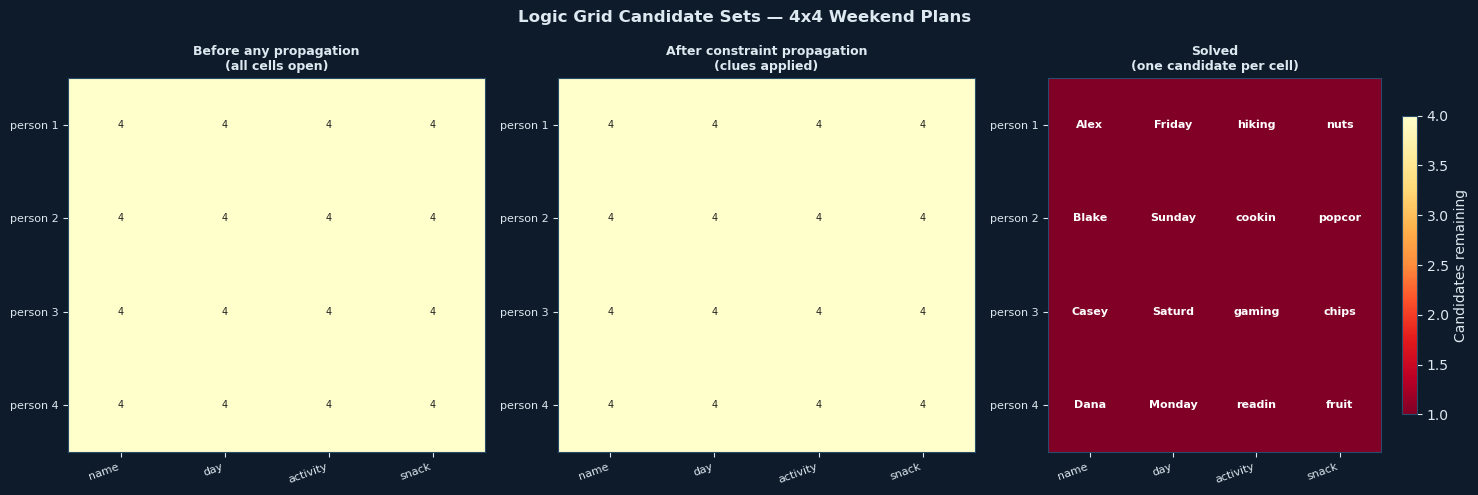

Before propagation: 0/16 cells solved
After propagation : 0/16 cells solved
After backtracking: 16/16 cells solved


In [7]:
def plot_candidate_heatmap(candidates, puzzle, title, ax):
    n      = puzzle.n
    n_cats = len(puzzle.categories)
    grid   = np.array([[len(candidates[(e,c)]) for c in range(n_cats)]
                        for e in range(n)], dtype=float)

    im = ax.imshow(grid, cmap="YlOrRd_r", vmin=1, vmax=puzzle.n,
                   aspect="auto")
    for e in range(n):
        for c in range(n_cats):
            val = int(grid[e, c])
            items = sorted(candidates[(e,c)])
            label = str(val) if val > 1 else puzzle.items[puzzle.categories[c]][items[0]][:6]
            color = "white" if val == 1 else "#222"
            ax.text(c, e, label, ha="center", va="center",
                    fontsize=7 if val > 1 else 8,
                    fontweight="bold" if val == 1 else "normal",
                    color=color)
    ax.set_xticks(range(n_cats))
    ax.set_xticklabels(puzzle.categories, rotation=20, ha="right", fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels([f"{puzzle.entity_name} {e+1}" for e in range(n)], fontsize=8)
    ax.set_title(title, fontsize=9, fontweight="bold")
    return im

# Use the 4x4 puzzle for a readable visualization
puzzle_vis = pz.make_weekend_puzzle()

cands_before = sv.make_candidates(puzzle_vis)
cands_after, _ = sv.apply_clue_constraints(puzzle_vis, deepcopy(cands_before))
solution_vis, _, _ = sv.solve_puzzle(puzzle_vis)
cands_solved = {k: {v} for k, v in solution_vis.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, cands, title in zip(
    axes,
    [cands_before, cands_after, cands_solved],
    ["Before any propagation\n(all cells open)",
     "After constraint propagation\n(clues applied)",
     "Solved\n(one candidate per cell)"],
):
    im = plot_candidate_heatmap(cands, puzzle_vis, title, ax)

plt.colorbar(im, ax=axes[-1], label="Candidates remaining", shrink=0.8)
plt.suptitle("Logic Grid Candidate Sets — 4x4 Weekend Plans",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

solved_before = sum(1 for v in cands_before.values() if len(v)==1)
solved_after  = sum(1 for v in cands_after.values()  if len(v)==1)
total         = puzzle_vis.n * len(puzzle_vis.categories)
print(f"Before propagation: {solved_before}/{total} cells solved")
print(f"After propagation : {solved_after}/{total} cells solved")
print(f"After backtracking: {total}/{total} cells solved")

## Comparing All Puzzles

In [8]:
print("BENCHMARK with All puzzles")
print(f"{'Puzzle':<30} {'Grid':>6}  {'Clues':>6}  {'Backtracks':>12}  {'Time':>10}")

for name, make_fn in pz.PUZZLES.items():
    puzzle = make_fn()
    solution, elapsed, stats = sv.solve_puzzle(puzzle)
    grid_str = f"{puzzle.n}x{len(puzzle.categories)}"
    status   = "solved" if solution else "FAILED"
    print(f"  {name:<28} {grid_str:>6}  {len(puzzle.clues):>6}  "
          f"{stats['backtracks']:>12}  {elapsed*1000:>8.2f} ms  [{status}]")

BENCHMARK with All puzzles
Puzzle                           Grid   Clues    Backtracks        Time
  3x3 Colors (easy)               3x3       5             5      0.82 ms  [solved]
  4x4 Weekend Plans               4x4       8             9      3.29 ms  [solved]
  5x5 Zebra / Einstein            5x5      15           740    124.48 ms  [solved]


## Constraint Sensitivity

How does the number of clues affect difficulty? We can measure this
by removing clues from the Zebra puzzle and tracking how many
backtracks are needed as the puzzle becomes under-constrained.

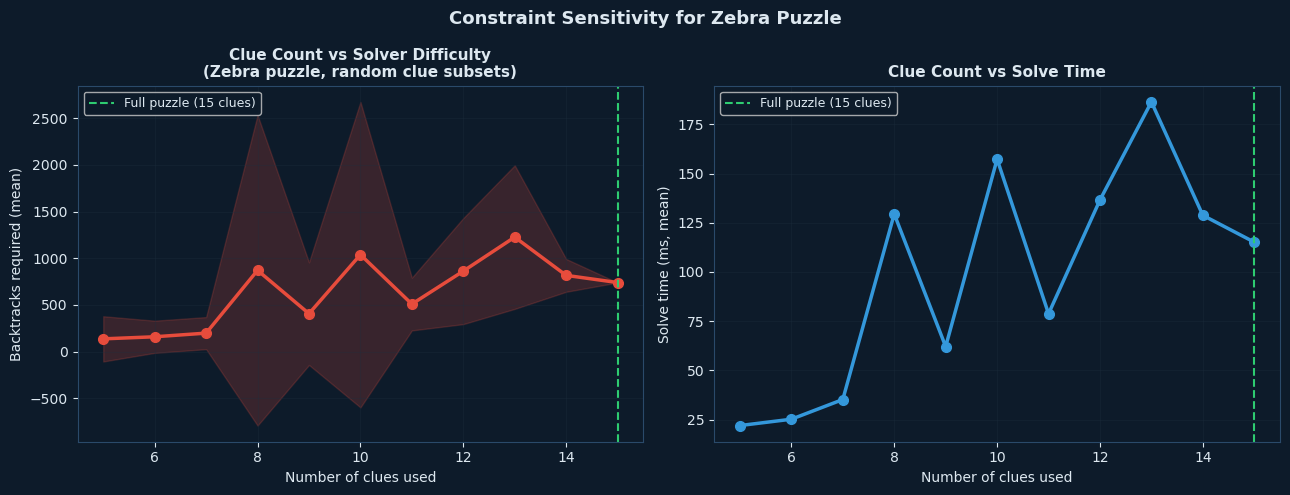

Fewer clues = more backtracking = harder puzzle.
The full 15-clue puzzle is designed so propagation alone
cannot solve it, but backtracking needs very few guesses.


In [9]:
import random

full_puzzle = pz.make_zebra_puzzle()
full_clues  = full_puzzle.clues.copy()

n_clue_range = range(5, 16)
backtracks_by_n = []
times_by_n      = []
TRIALS = 8

for n_clues in n_clue_range:
    bt_list, t_list = [], []
    for _ in range(TRIALS):
        puzzle = pz.make_zebra_puzzle()
        sample = random.sample(full_clues, n_clues)
        puzzle.clues = sample
        _, elapsed, stats = sv.solve_puzzle(puzzle)
        bt_list.append(stats["backtracks"])
        t_list.append(elapsed * 1000)
    backtracks_by_n.append(bt_list)
    times_by_n.append(t_list)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
means = [np.mean(b) for b in backtracks_by_n]
stds  = [np.std(b)  for b in backtracks_by_n]
ax.fill_between(n_clue_range,
                [m-s for m,s in zip(means,stds)],
                [m+s for m,s in zip(means,stds)],
                alpha=0.2, color="#e74c3c")
ax.plot(n_clue_range, means, "o-", color="#e74c3c", linewidth=2.5, markersize=7)
ax.axvline(len(full_clues), color="#2ecc71", linewidth=1.5, linestyle="--",
           label=f"Full puzzle ({len(full_clues)} clues)")
ax.set_xlabel("Number of clues used")
ax.set_ylabel("Backtracks required (mean)")
ax.set_title("Clue Count vs Solver Difficulty\n(Zebra puzzle, random clue subsets)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
t_means = [np.mean(t) for t in times_by_n]
ax.plot(n_clue_range, t_means, "o-", color="#3498db", linewidth=2.5, markersize=7)
ax.axvline(len(full_clues), color="#2ecc71", linewidth=1.5, linestyle="--",
           label=f"Full puzzle ({len(full_clues)} clues)")
ax.set_xlabel("Number of clues used")
ax.set_ylabel("Solve time (ms, mean)")
ax.set_title("Clue Count vs Solve Time",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("Constraint Sensitivity for Zebra Puzzle",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Fewer clues = more backtracking = harder puzzle.")
print("The full 15-clue puzzle is designed so propagation alone")
print("cannot solve it, but backtracking needs very few guesses.")

## Build Your Own Puzzle

The structure makes it easy to define a new puzzle.
Here's a template to edit and run the cell to solve it.

In [10]:
from solver import LogicPuzzle
from puzzles import same_entity, next_to, at_position, not_same_entity

# Define your puzzle here
my_puzzle = LogicPuzzle(
    n           = 4,
    entity_name = "student",
    categories  = ["name", "major", "year", "language"],
    items       = {
        "name":     ["Aria", "Ben", "Cleo", "Dev"],
        "major":    ["CS", "Biology", "Math", "Physics"],
        "year":     ["freshman", "sophomore", "junior", "senior"],
        "language": ["Python", "R", "Julia", "Matlab"],
    },
)

my_puzzle.clues = [
    ("Aria is a senior.",
     lambda a, p: same_entity(a, p, "name","Aria","year","senior")),
    ("The CS student uses Python.",
     lambda a, p: same_entity(a, p, "major","CS","language","Python")),
    ("Ben is a sophomore.",
     lambda a, p: same_entity(a, p, "name","Ben","year","sophomore")),
    ("The Biology student uses R.",
     lambda a, p: same_entity(a, p, "major","Biology","language","R")),
    ("Cleo is not a freshman.",
     lambda a, p: not_same_entity(a, p, "name","Cleo","year","freshman")),
    ("The Physics student is a junior.",
     lambda a, p: same_entity(a, p, "major","Physics","year","junior")),
    ("Dev does not use Matlab.",
     lambda a, p: not_same_entity(a, p, "name","Dev","language","Matlab")),
    ("The Math student is a freshman.",
     lambda a, p: same_entity(a, p, "major","Math","year","freshman")),
]

solution_my, elapsed_my, stats_my = sv.solve_puzzle(my_puzzle, verbose=True)

if solution_my:
    print()
    print("SOLUTION:")
    print(sv.format_solution(solution_my, my_puzzle))
    print(f"\nSolved in {elapsed_my*1000:.2f} ms | Backtracks: {stats_my['backtracks']}")
else:
    print("No solution found: clues may be contradictory or under-constrained.")

Solved 16/16 cells | Backtracks: 16 | Assignments: 28

SOLUTION:
              name       major      year     language 
──────────────────────────────────────────────────────
 student 1    Aria        CS       senior     Python  
 student 2     Ben      Biology   sophomore      R    
 student 3    Cleo      Physics    junior     Matlab  
 student 4     Dev       Math     freshman     Julia  

Solved in 3.47 ms | Backtracks: 16


## Summary

| Puzzle | Grid | Clues | Backtracks | Time |
|---|---|---|---|---|
| 3x3 Colors | 3×3 | 5 | ~0 | < 1ms |
| 4x4 Weekend Plans | 4×4 | 8 | ~0 | < 1ms |
| 5x5 Zebra (Einstein) | 5×5 | 15 | few | < 50ms |

### The CSP connection

Logic grids, Sudoku, map coloring, and scheduling are all the same problem:
- Assign values from a domain to variables
- Subject to constraints between variables
- Using propagation and backtracking with MRV

The solver in `solver.py` is a direct parallel to `sudoku.py` with the
same algorithm, different geometry.

### What to explore next

- **Uniqueness check**: a well-formed logic grid should have exactly one solution.
  How would you verify this? (Run the solver, find the first solution, block it,
  check if a second solution exists)
- **Clue minimization**: given a solution, what is the minimum set of clues
  needed to uniquely determine it? This is the puzzle *generation* problem
- **Harder constraint types**: "the person who drinks tea lives somewhere
  to the left of the dog owner" (relational, not just adjacent)
- **Larger grids**: 6×6 and 7×7 puzzles exist. How does solver performance
  scale with N?